In [68]:
import pandas as pd
import os

df1 = pd.read_csv("../data/raw/pl_25-26.csv")
df2 = pd.read_csv("../data/raw/pl_24-25.csv")
df3 = pd.read_csv("../data/raw/pl_23-24.csv")

df1['Season'] = '2025/26'
df2['Season'] = '2024/25'
df3['Season'] = '2023/24'

df = pd.concat([df1, df2, df3], ignore_index=True)

print(df.shape)
print(df.columns.tolist())

(1140, 163)
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'BWCH', 'BWCD', 'BWCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2

In [69]:
city_home = df[df['HomeTeam'] == 'Man City'].copy()
city_away = df[df['AwayTeam'] == 'Man City'].copy()

print(f"City Home: {len(city_home)}")
print(f"City Away: {len(city_away)}")
print(f"Total: {len(city_home) + len(city_away)}")

City Home: 57
City Away: 57
Total: 114


In [70]:
city_home['corners'] = city_home['HC']
city_away['corners'] = city_away['AC']

city_all = pd.concat([city_home, city_away], ignore_index=True)
print(f"Average corners per match: {city_all['corners'].mean():.2f}")
print(f"Home average: {city_home['HC'].mean():.2f}")
print(f"Away average: {city_away['AC'].mean():.2f}")
print(f"Min: {city_all['corners'].min()}")
print(f"Max: {city_all['corners'].max()}")

seasonal = city_all.groupby('Season')['corners'].agg(['mean', 'std', 'min', 'max', 'count'])

print(seasonal)

Average corners per match: 6.86
Home average: 7.44
Away average: 6.28
Min: 0
Max: 18
             mean       std  min  max  count
Season                                      
2023/24  7.421053  3.873901    0   15     38
2024/25  6.657895  3.772420    1   18     38
2025/26  6.500000  3.202617    2   15     38


In [71]:
city_home['opponent'] = city_home['AwayTeam']
city_away['opponent'] = city_away['HomeTeam']

city_all = pd.concat([city_home, city_away], ignore_index=True)

opponent_corners = (
    city_all
    .groupby(['opponent', 'Season'])['corners']
    .agg(['mean', 'count'])
    .reset_index()
    .sort_values(['opponent', 'Season'], ascending=True)
)

print(opponent_corners.to_string())

            opponent   Season  mean  count
0            Arsenal  2023/24   5.5      2
1            Arsenal  2024/25   5.0      2
2            Arsenal  2025/26   5.0      2
3        Aston Villa  2023/24   1.0      2
4        Aston Villa  2024/25   7.0      2
5        Aston Villa  2025/26   7.5      2
6        Bournemouth  2023/24  10.0      2
7        Bournemouth  2024/25   6.5      2
8        Bournemouth  2025/26   8.0      2
9          Brentford  2023/24  11.5      2
10         Brentford  2024/25   8.5      2
11         Brentford  2025/26   6.0      2
12          Brighton  2023/24   3.0      2
13          Brighton  2024/25   4.0      2
14          Brighton  2025/26   4.0      2
15           Burnley  2023/24   6.0      2
16           Burnley  2025/26  10.5      2
17           Chelsea  2023/24   7.5      2
18           Chelsea  2024/25   2.5      2
19           Chelsea  2025/26  10.0      2
20    Crystal Palace  2023/24   7.5      2
21    Crystal Palace  2024/25   4.5      2
22    Cryst

In [72]:
city_home['Date'] = pd.to_datetime(city_home['Date'], dayfirst=True)
city_away['Date'] = pd.to_datetime(city_away['Date'], dayfirst=True)

city_home = city_home.sort_values('Date').copy()
city_away = city_away.sort_values('Date').copy()

city_home['city_rolling_corners'] = (
    city_home['HC']
    .shift(1)
    .rolling(window=5, min_periods=1)
    .mean()
)

city_away['city_rolling_corners'] = (
    city_away['AC']
    .shift(1)
    .rolling(window=5, min_periods=1)
    .mean()
)

print(city_home[['Date', 'HomeTeam', 'AwayTeam', 'HC', 'city_rolling_corners']].head(10))

          Date  HomeTeam          AwayTeam  HC  city_rolling_corners
775 2023-08-19  Man City         Newcastle   3                   NaN
794 2023-09-02  Man City            Fulham   4              3.000000
811 2023-09-23  Man City     Nott'm Forest   6              3.500000
843 2023-10-21  Man City          Brighton   2              4.333333
864 2023-11-04  Man City       Bournemouth  12              3.750000
880 2023-11-25  Man City         Liverpool   9              5.400000
899 2023-12-03  Man City         Tottenham  10              6.600000
922 2023-12-16  Man City    Crystal Palace   6              7.800000
951 2023-12-30  Man City  Sheffield United  12              7.800000
973 2024-01-31  Man City           Burnley   7              9.800000


In [73]:
home_conceded = df[['Date', 'HomeTeam', 'AC']].copy()
home_conceded.columns = ['date', 'team', 'corners_conceded']

away_conceded = df[['Date', 'AwayTeam', 'HC']].copy()
away_conceded.columns = ['date', 'team', 'corners_conceded']

all_conceded = pd.concat([home_conceded, away_conceded], ignore_index=True)

all_conceded['date'] = pd.to_datetime(all_conceded['date'], dayfirst=True)
all_conceded = all_conceded.sort_values(['team', 'date']).reset_index(drop=True)

print(all_conceded.shape)
print(all_conceded.head(10))

(2280, 3)
        date     team  corners_conceded
0 2023-08-12  Arsenal                 3
1 2023-08-21  Arsenal                 1
2 2023-08-26  Arsenal                 3
3 2023-09-03  Arsenal                 3
4 2023-09-17  Arsenal                 1
5 2023-09-24  Arsenal                 4
6 2023-09-30  Arsenal                 6
7 2023-10-08  Arsenal                 4
8 2023-10-21  Arsenal                 2
9 2023-10-28  Arsenal                 1


In [74]:
all_conceded['rolling_conceded'] = (
    all_conceded
    .groupby('team')['corners_conceded']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

print(all_conceded.head(10))

        date     team  corners_conceded  rolling_conceded
0 2023-08-12  Arsenal                 3               NaN
1 2023-08-21  Arsenal                 1          3.000000
2 2023-08-26  Arsenal                 3          2.000000
3 2023-09-03  Arsenal                 3          2.333333
4 2023-09-17  Arsenal                 1          2.500000
5 2023-09-24  Arsenal                 4          2.200000
6 2023-09-30  Arsenal                 6          2.400000
7 2023-10-08  Arsenal                 4          3.400000
8 2023-10-21  Arsenal                 2          3.600000
9 2023-10-28  Arsenal                 1          3.400000


In [75]:
all_conceded = all_conceded.dropna(subset=['rolling_conceded'])

city_all = pd.concat([city_home, city_away], ignore_index=True)
city_all['opponent'] = city_all.apply(
    lambda row: row['AwayTeam'] if row['HomeTeam'] == 'Man City' else row['HomeTeam'],
    axis=1
)

city_all['Date'] = pd.to_datetime(city_all['Date'], dayfirst=True)

city_all = city_all.merge(
    all_conceded[['date', 'team', 'rolling_conceded']],
    left_on=['Date', 'opponent'],
    right_on=['date', 'team'],
    how='left'
)

print(city_all[['opponent', 'corners', 'city_rolling_corners', 'rolling_conceded']].head(10))

           opponent  corners  city_rolling_corners  rolling_conceded
0         Newcastle        3                   NaN          5.000000
1            Fulham        4              3.000000          7.666667
2     Nott'm Forest        6              3.500000          7.600000
3          Brighton        2              4.333333          3.400000
4       Bournemouth       12              3.750000          7.000000
5         Liverpool        9              5.400000          5.400000
6         Tottenham       10              6.600000          7.200000
7    Crystal Palace        6              7.800000          4.400000
8  Sheffield United       12              7.800000          7.200000
9           Burnley        7              9.800000          6.400000


In [76]:
city_all['is_home'] = (city_all['HomeTeam'] == 'Man City').astype(int)
city_all = city_all.dropna(subset=['city_rolling_corners', 'rolling_conceded'])
print(f"Matches after dropping NaN: {len(city_all)}")
print(f"\nNaN counts:\n{city_all[['city_rolling_corners', 'rolling_conceded', 'is_home']].isna().sum()}")

Matches after dropping NaN: 112

NaN counts:
city_rolling_corners    0
rolling_conceded        0
is_home                 0
dtype: int64


In [77]:
import torch
import torch.nn as nn
import torch.optim as optim

features = ['city_rolling_corners', 'rolling_conceded', 'is_home']
target = 'corners'

X = torch.tensor(city_all[features].values, dtype=torch.float32)
y = torch.tensor(city_all[target].values, dtype=torch.float32)

print(X.shape)
print(y.shape)

torch.Size([112, 3])
torch.Size([112])


In [78]:
model = nn.Sequential(
    nn.Linear(3, 1),
    nn.Softplus()
)

criterion = nn.PoissonNLLLoss(log_input=False)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
  (1): Softplus(beta=1.0, threshold=20.0)
)


In [79]:
loss_history = []

for epoch in range(1000):
    model.train()

    y_pred = model(X).squeeze()

    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: -5.8371
Epoch 100 | Loss: -6.5423
Epoch 200 | Loss: -6.5445
Epoch 300 | Loss: -6.5458
Epoch 400 | Loss: -6.5468
Epoch 500 | Loss: -6.5477
Epoch 600 | Loss: -6.5485
Epoch 700 | Loss: -6.5493
Epoch 800 | Loss: -6.5499
Epoch 900 | Loss: -6.5505


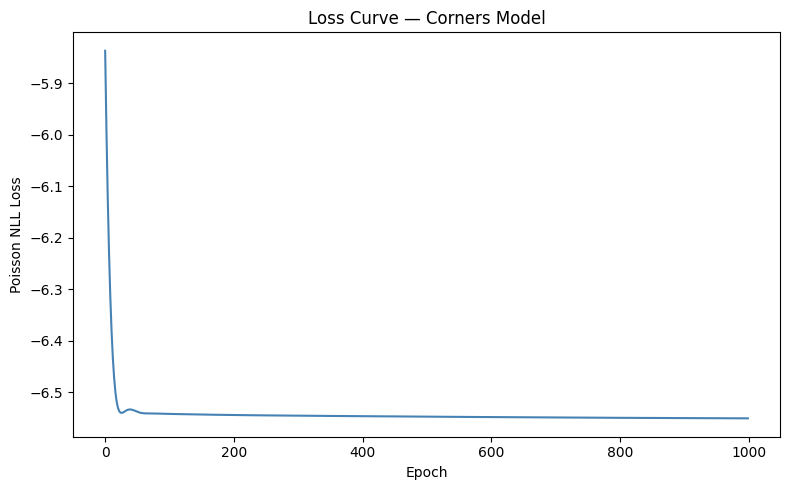

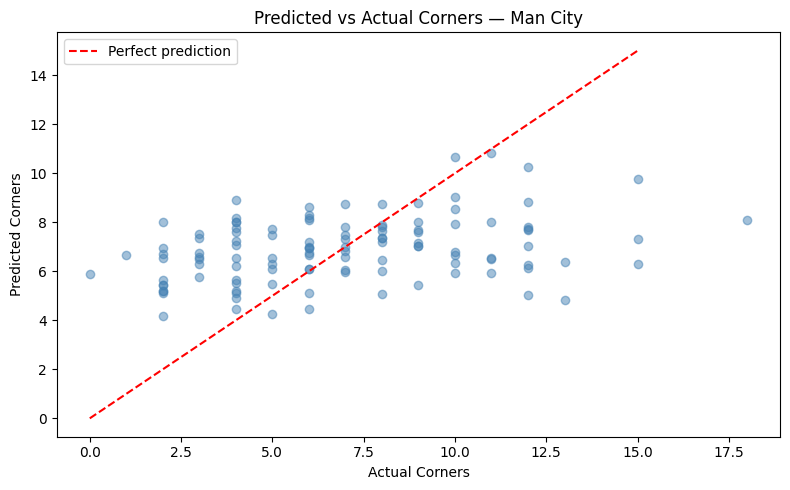

Mean predicted corners: 6.91
Mean actual corners: 6.91


In [80]:
with torch.no_grad():
    predictions = model(X).squeeze()

predictions_np = predictions.numpy()
actual_np = y.numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='steelblue')
plt.title("Loss Curve — Corners Model")
plt.xlabel("Epoch")
plt.ylabel("Poisson NLL Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(actual_np, predictions_np, alpha=0.5, color='steelblue')
plt.plot([0, 15], [0, 15], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("Actual Corners")
plt.ylabel("Predicted Corners")
plt.title("Predicted vs Actual Corners — Man City")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean predicted corners: {predictions_np.mean():.2f}")
print(f"Mean actual corners: {actual_np.mean():.2f}")

In [81]:
baseline = actual_np.mean()
baseline_errors = (actual_np - baseline) ** 2
model_errors = (predictions_np - actual_np) ** 2

print(f"Baseline MSE (always predict mean): {baseline_errors.mean():.4f}")
print(f"Model MSE: {model_errors.mean():.4f}")

Baseline MSE (always predict mean): 13.0456
Model MSE: 11.5602


In [82]:
# Cell 1 - drop NaNs before concat
city_home = city_home.dropna(subset=['city_rolling_corners'])
city_away = city_away.dropna(subset=['city_rolling_corners'])

print(f"Home: {len(city_home)}")
print(f"Away: {len(city_away)}")

Home: 56
Away: 56
